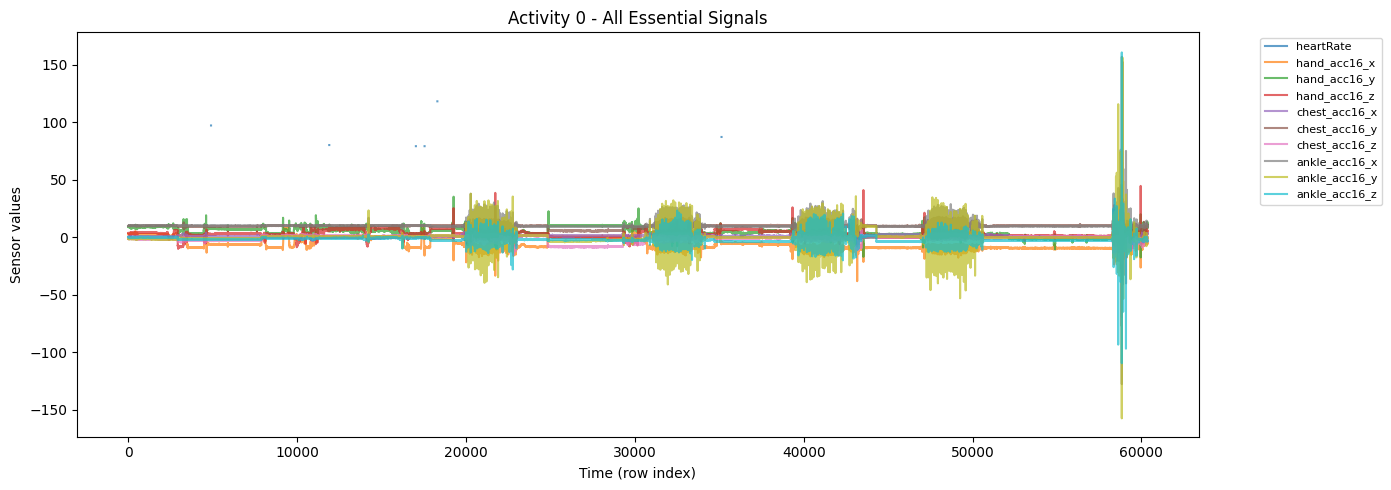

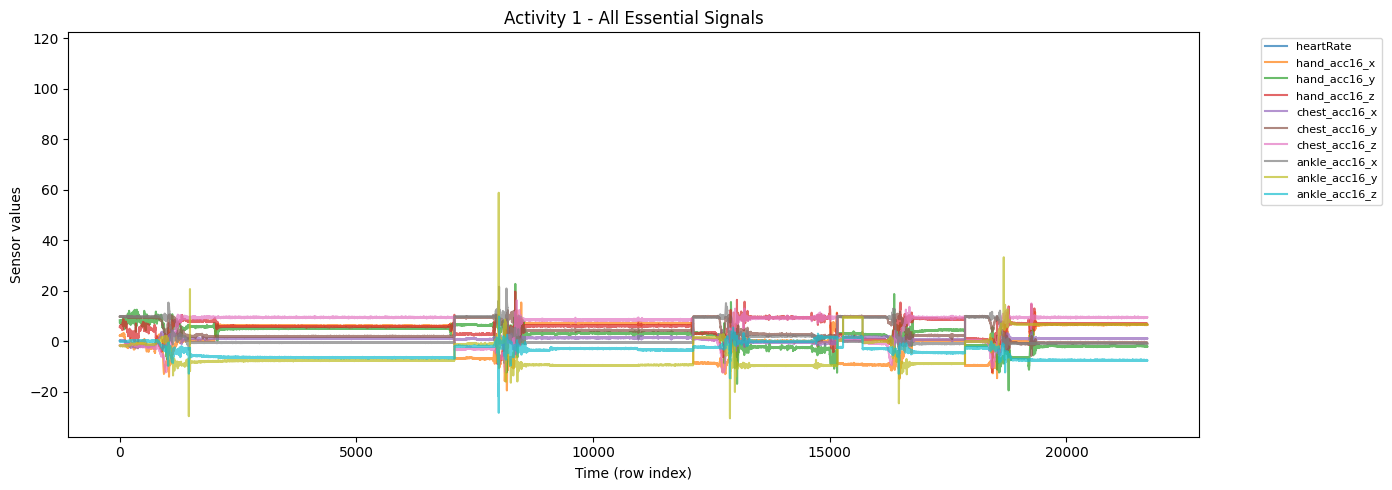

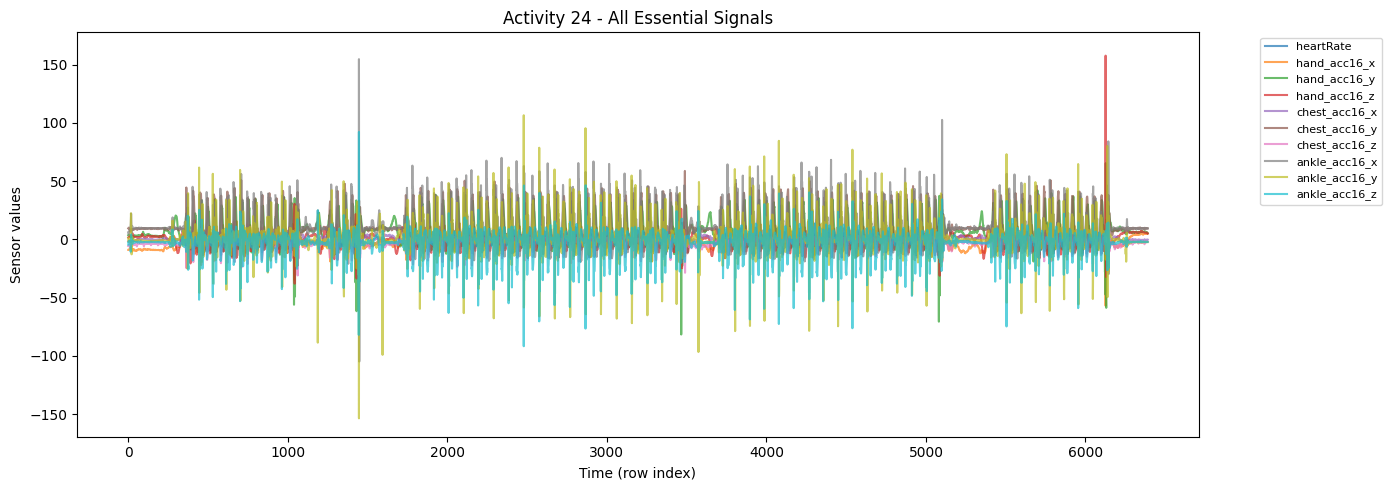

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset
df = pd.read_csv("pamap2_combined.csv")

# 2. Choose essential columns for plotting
cols_to_plot = [
    'heartRate',
    'hand_acc16_x', 'hand_acc16_y', 'hand_acc16_z',
    'chest_acc16_x', 'chest_acc16_y', 'chest_acc16_z',
    'ankle_acc16_x', 'ankle_acc16_y', 'ankle_acc16_z'
]

# 3. Plot for each activity
for act_id in range(25):
    df_act = df[df['activityID'] == act_id]
    if df_act.empty:
        continue  # skip if no data for this activity

    plt.figure(figsize=(14, 5))
    plt.title(f"Activity {act_id} - All Essential Signals")
    
    for col in cols_to_plot:
        plt.plot(df_act[col].values, label=col, alpha=0.7)
    
    plt.xlabel("Time (row index)")
    plt.ylabel("Sensor values")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv("pamap2_combined.csv")
X = df.drop(columns=["timestamp", "activityID"])
y = df["activityID"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=True)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(16, activation='relu')(encoded)
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_split=0.1)


Epoch 1/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: nan - val_loss: nan
Epoch 2/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 3/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 4/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 5/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 6/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 7/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 8/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 9/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 10/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 11/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 12/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 13/50
1

Epoch 1/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 2/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 3/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 4/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 5/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 6/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 7/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 8/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 9/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 10/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 11/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 12/50
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: nan - val_loss: nan
Epoch 13/50
1

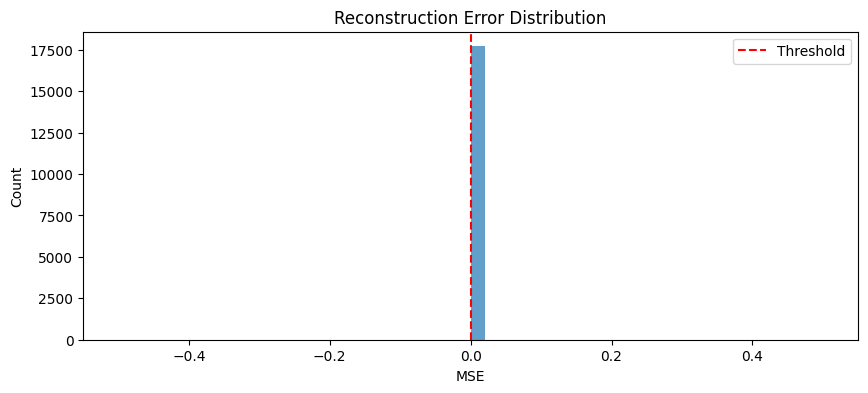

In [9]:
import numpy as np

X_train_clean = np.nan_to_num(X_train, nan=0.0, posinf=1e5, neginf=-1e5)
X_test_clean  = np.nan_to_num(X_test, nan=0.0, posinf=1e5, neginf=-1e5)

autoencoder.fit(X_train_clean, X_train_clean, epochs=50, batch_size=32, validation_split=0.1)

X_pred = autoencoder.predict(X_test_clean)
mse = np.mean(np.power(X_test_clean - X_pred, 2), axis=1)

# Remove any remaining NaNs
mse = np.nan_to_num(mse, nan=0.0)

threshold = np.percentile(mse, 95)
anomalies = mse > threshold
n_anomalies = np.sum(anomalies)

print(f"Total test samples: {len(X_test_clean)}")
print(f"Anomalies detected: {n_anomalies}")
print(f"Anomaly percentage: {n_anomalies/len(X_test_clean)*100:.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(mse, bins=50, alpha=0.7)
plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Count")
plt.legend()
plt.show()


Created DataFrames for 3 activities

Processing Activity 0 ...
378/378 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Activity 0: Total samples=12075, Anomalies detected=604


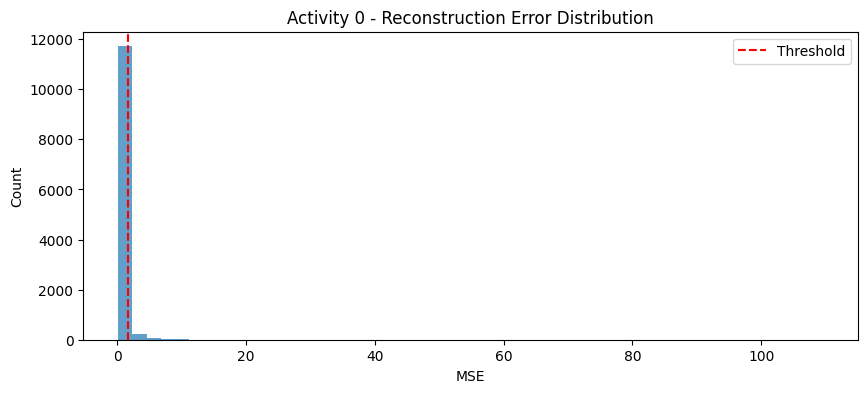


Processing Activity 1 ...
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Activity 1: Total samples=4343, Anomalies detected=218


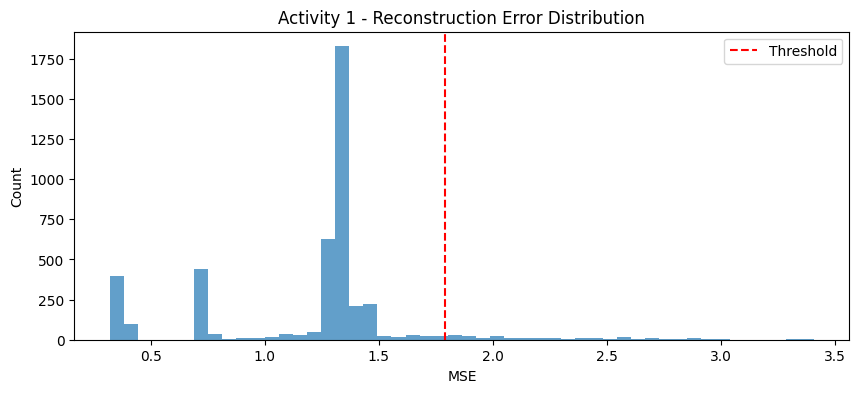


Processing Activity 24 ...
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Activity 24: Total samples=1279, Anomalies detected=64


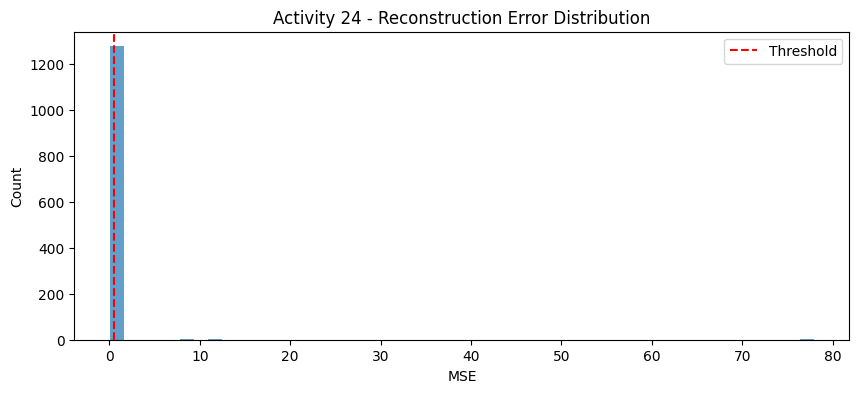


Anomaly Detection Summary per Activity:
   activity  total_samples  anomalies  anomaly_percent
0         0          12075        604         5.002070
1         1           4343        218         5.019572
2        24           1279         64         5.003909


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt

# 1️⃣ Load dataset
df = pd.read_csv("pamap2_combined.csv")

# 2️⃣ Create 25 activity DataFrames
activity_dfs = {}
for act_id in range(25):
    df_act = df[df['activityID'] == act_id].reset_index(drop=True)
    if not df_act.empty:
        activity_dfs[act_id] = df_act

print(f"Created DataFrames for {len(activity_dfs)} activities")

# 3️⃣ Loop over each activity
results = []

for act_id, df_act in activity_dfs.items():
    print(f"\nProcessing Activity {act_id} ...")
    
    # 3a. Drop non-sensor columns
    X = df_act.drop(columns=["timestamp", "activityID"])
    
    # 3b. Clean NaNs/Infs
    X = np.nan_to_num(X, nan=0.0, posinf=1e5, neginf=-1e5)
    
    # 3c. Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 3d. Split train/test (80/20)
    split_idx = int(0.8 * X_scaled.shape[0])
    X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    
    # 3e. Build autoencoder
    input_dim = X_train.shape[1]
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(16, activation='relu')(encoded)
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(decoded)
    decoded = Dense(input_dim, activation='linear')(decoded)
    autoencoder = Model(inputs=input_layer, outputs=decoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    
    # 3f. Train autoencoder
    autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
    
    # 3g. Predict reconstruction
    X_pred = autoencoder.predict(X_test)
    
    # 3h. Compute reconstruction error
    mse = np.mean(np.power(X_test - X_pred, 2), axis=1)
    mse = np.nan_to_num(mse, nan=0.0)
    
    # 3i. Detect anomalies (95th percentile threshold)
    threshold = np.percentile(mse, 95)
    anomalies = mse > threshold
    n_anomalies = np.sum(anomalies)
    
    print(f"Activity {act_id}: Total samples={X_test.shape[0]}, Anomalies detected={n_anomalies}")
    
    results.append({
        "activity": act_id,
        "total_samples": X_test.shape[0],
        "anomalies": n_anomalies,
        "anomaly_percent": n_anomalies / X_test.shape[0] * 100
    })
    
    # 3j. Plot reconstruction error histogram
    plt.figure(figsize=(10,4))
    plt.hist(mse, bins=50, alpha=0.7)
    plt.axvline(threshold, color='r', linestyle='--', label='Threshold')
    plt.title(f"Activity {act_id} - Reconstruction Error Distribution")
    plt.xlabel("MSE")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

# 4️⃣ Summary DataFrame
summary_df = pd.DataFrame(results)
print("\nAnomaly Detection Summary per Activity:")
print(summary_df)


In [11]:
import pandas as pd

df = pd.read_csv("pamap2_combined.csv")

activity_counts = df['activityID'].value_counts().sort_index()

print("Number of records per activity:")
for act_id, count in activity_counts.items():
    print(f"Activity {act_id}: {count}")


Number of records per activity:
Activity 0: 60375
Activity 1: 21711
Activity 24: 6391


In [ ]:
#graph neural network specially for multmodal wearable data

In [17]:
import pandas as pd
import torch
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import SAGEConv
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1️⃣ Load dataset
df = pd.read_csv("pamap2_combined.csv")

# Drop timestamp
X = df.drop(columns=['timestamp'])
y = X.pop('activityID')

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert to tensor
X = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y, dtype=torch.long)

# 2️⃣ Create temporal graphs
window_size = 50   # timestamps per graph
edge_k = 5         # each node connected to next 5 nodes
graphs = []

for start in range(0, len(X) - window_size, window_size):
    X_win = X[start:start+window_size]
    y_win = y[start:start+window_size]
    
    # Create sparse edges
    edge_index = []
    for i in range(window_size):
        for j in range(1, edge_k+1):
            if i+j < window_size:
                edge_index.append([i, i+j])
    edge_index = torch.tensor(edge_index, dtype=torch.long).t()
    
    data = Data(x=X_win, y=y_win, edge_index=edge_index)
    graphs.append(data)

# 3️⃣ Train/test split
train_graphs, test_graphs = train_test_split(graphs, test_size=0.2, random_state=42)
train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_graphs, batch_size=16, shuffle=False)

# 4️⃣ Define GraphSAGE model
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphSAGE(in_channels=X.shape[1], hidden_channels=64, out_channels=len(le.classes_)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

# 5️⃣ Training loop
for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# 6️⃣ Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)

accuracy = correct / total
print(f"\nTest Accuracy: {accuracy*100:.2f}%")


C:\Python310\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 1, Loss: nan
Epoch 2, Loss: nan
Epoch 3, Loss: nan
Epoch 4, Loss: nan
Epoch 5, Loss: nan
Epoch 6, Loss: nan
Epoch 7, Loss: nan
Epoch 8, Loss: nan
Epoch 9, Loss: nan
Epoch 10, Loss: nan

Test Accuracy: 67.93%


In [ ]:
#pip install torch

In [ ]:
#pip install torch_geometric